#Yannick Poirier, POIY04109403
##INF1008 - TP2



---



Initialisation de l'algorithme génétique et chargement des données...
Début du processus d'évolution.
Initialisation de la population de chromosomes...
generation: 0


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


generation: 1


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


generation: 2


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


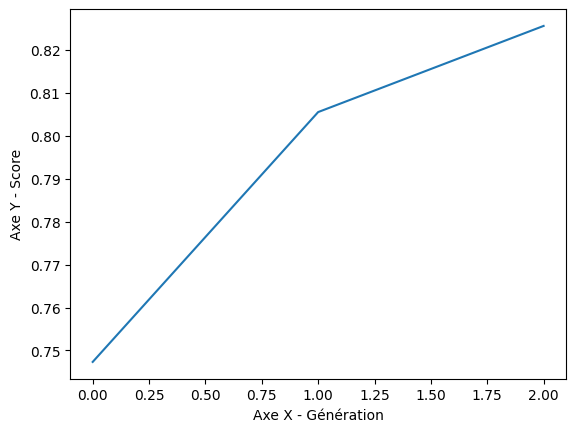

Meilleures configurations trouvées:
[{'fitness': 0.9733333333333334, 'gene_hidden_layer_size': (100,), 'gene_max_iter': 1000, 'gene_solver': 'lbfgs', 'gene_learning_rate': 0.005}, {'fitness': 0.9733333333333334, 'gene_hidden_layer_size': (100,), 'gene_max_iter': 1000, 'gene_solver': 'lbfgs', 'gene_learning_rate': 0.01}, {'fitness': 0.9711111111111111, 'gene_hidden_layer_size': (100,), 'gene_max_iter': 100, 'gene_solver': 'adam', 'gene_learning_rate': 0.001}, {'fitness': 0.9688888888888889, 'gene_hidden_layer_size': (50, 50), 'gene_max_iter': 100, 'gene_solver': 'adam', 'gene_learning_rate': 0.001}, {'fitness': 0.9688888888888889, 'gene_hidden_layer_size': (50,), 'gene_max_iter': 500, 'gene_solver': 'lbfgs', 'gene_learning_rate': 0.005}]
Fin des générations


In [5]:
# Le code est complet et fonctionnel ici.   (0 point)
# Importer les bibliothèques nécessaires
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.metrics import accuracy_score
import random
import matplotlib.pyplot as plt
from statistics import mean

class algo_genetique:
    """
    Classe implémentant un algorithme génétique pour l'optimisation d'un modèle MLP.

    Attributes:
    - digits (obj): Les données MNIST.
    - X_train (array): Les données d'entraînement.
    - X_test (array): Les données de test.
    - y_train (array): Les étiquettes d'entraînement.
    - y_test (array): Les étiquettes de test.
    - gene_hidden_layer_sizes (list): Le domaine des valeurs possibles pour la taille de la couche cachée.
    - gene_max_iter (list): Le domaine des valeurs possibles pour le nombre maximal d'itérations.
    - gene_solver (list): Le domaine des valeurs possibles pour le solveur du modèle MLP.
    - gene_learning_rate (list): Le domaine des valeurs possibles pour le taux d'apprentissage du modèle MLP.
    - population_chromosomes (list): La population de chromosomes représentant les configurations du modèle MLP.
    - nb_generation_max (int): Le nombre maximal de générations à effectuer.
    - taux_mutation (float): Le taux de mutation dans l'algorithme génétique.
    - taille_population (int): La taille de la population de chromosomes.
    - nombre_meilleurs_conserves (int): Le nombre de meilleurs chromosomes conservés à chaque génération.

    Methods:
    - __init__(): Le constructeur de la classe, initialise les données et divise l'ensemble de données MNIST.
    - random_initial_population(): Initialise la population initiale de chromosomes de manière aléatoire.
    - mutate(individual): Mutate un individu en choisissant de nouvelles valeurs parmi les gènes permis.
    - breeding(parent1, parent2): Reproduit deux individus (crossover) avec mutation éventuelle.
    - selection(): Sélectionne les meilleurs individus de la population et applique la reproduction aux individus restants.
    - fitness(chromosome): Évalue la performance d'un chromosome en utilisant un modèle MLP.
    - evolution(): Simule le processus d'évolution de la population de chromosomes.
    - affiche_graphique(graphique_performance_moyenne): Affiche un graphique de la performance moyenne au fil des générations.
    """

    # Propriétés
    digits = None
    X_train = None
    X_test = None
    y_train = None
    y_test = None

    # Définition du domaine des gênes. (valeurs possibles pour chacun)
    gene_hidden_layer_sizes = [(2,), (5,), (50,), (100,), (50, 50,), (10, 10, 10,)]
    gene_max_iter = [100, 500, 1000, 5000]
    gene_solver = ["adam", "lbfgs", "sgd"]
    gene_learning_rate = [0.01, 0.005, 0.001]

    # Le vecteur des chromosomes
    population_chromosomes = []

    # Paramètres importants de l'algorithme génétiques
    # Nombre de génération maximal à effectuer
    nb_generation_max = 3
    # Le taux de mutation
    taux_mutation = 0.05
    # La taille de la population de chromosomes
    taille_population = 10
    # Le nombre de chromosomes conservés (les meilleurs) par génération
    nombre_meilleurs_conserves = 5

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------#

    ''' Complétez la méthode (2 point)
    Méthode __init__() : L'algorithme génétique est initialisé à l'aide de la BD MNIST. Les données
    sont ensuite divisée pour l'entrainement et test '''

    def __init__(self):
        print("Initialisation de l'algorithme génétique et chargement des données...")

        # Charger la base de données MNIST
        self.digits = datasets.load_digits()

        # Diviser les données en ensembles d'entraînement (75%) et de test (25%)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.digits.data, self.digits.target, test_size=0.25, random_state=1)


#---------------------------------------------------------------------------------------------------------------------------------------------------------------------#

    ''' Complétez la méthode (2 point)
    Méthode random_initial_population() : Initialisation de la population initiale des chromosomes
    en sélectionnant aléatoirement les gènes de chacun selon les valeurs possibles. '''

    def random_initial_population(self):
        print("Initialisation de la population de chromosomes...")

        for i in range(self.taille_population): # itère sur le nombre de chromosomes de la population
            gene_hidden_layer_size = random.choice(self.gene_hidden_layer_sizes) # Selection aléatoire d'une couche caché
            gene_max_iter = random.choice(self.gene_max_iter) # itération max choisis au hasard parmis ceux spécifier
            gene_solver = random.choice(self.gene_solver) # le solveur choisis au hasard parmis ceux spécifier
            gene_learning_rate = random.choice(self.gene_learning_rate) # le taux d'apprentissage choisis au hasard parmis ceux spécifier

            # Chromosome créer à partir des valeurs aléatoire de la boucle for
            un_chromosome = {
                'fitness': None, # Définis lors de la performence du modèle
                'gene_hidden_layer_size': gene_hidden_layer_size, # Configuration du RDN
                'gene_max_iter': gene_max_iter, # itération max
                'gene_solver': gene_solver, # type d'apprentissage
                'gene_learning_rate': gene_learning_rate # taux d'apprentissage
            }
            # Chaque chromosomes créer est ajouté à la liste de la population 'self.population_chromosomes'
            self.population_chromosomes.append(un_chromosome)

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------#

    ''' Complétez la méthode (2 point)
    Méthode mutate() : Mutation d'un individu en choisissant une nouvelle valeur parmi les gènes permis.

      Paramètre :
        - individual (dict): Individu à muter.

      Retourne :
        - mutated_individual (dict): Individu muté. '''

    def mutate(self, individual):

        # Copie du vecteur individual dans une nouvelle variable (mutated_individual)
        mutated_individual = individual.copy()

        # Mutation de l'un des gène
        # Le choix aléatoire d'une clé dans le dictionnaire représentant un individu. La clé correspond à un gène spécifique.
        key = random.choice(list(mutated_individual.keys()))

        # En fonction de la clé, selection aléatoire d'une nouvelle valeur permis pour le gène
        if key == "gene_hidden_layer_size":
            mutated_individual[key] = random.choice(self.gene_hidden_layer_sizes)
        elif key == "gene_max_iter":
            mutated_individual[key] = random.choice(self.gene_max_iter)
        elif key == "gene_solver":
            mutated_individual[key] = random.choice(self.gene_solver)
        elif key == "gene_learning_rate":
            mutated_individual[key] = random.choice(self.gene_learning_rate)

        # Retourne l'individu qui a été muté
        return mutated_individual

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------#

    ''' Complétez la méthode (2 point)
    Méthode breeding() : Reproduction des individus (crossover) avec les mutations éventuelle

      Paramètres :
        - parent1 (dict): Premier parent
        - parent2 (dict): Deuxième parent

        Retourne :
        - child (dict): Nouvel individu résultant de la reproduction. '''

    def breeding(self, parent1, parent2):

        # Création d'un dictionnaire vide (child) qui va représenter nouvel individu
        child = {}

        # Un point de crossover est choisi aléatoirement entre 1 et la taille du chromosome parent 1.
        # Pour l'enfant, les genes avant crossover_point vont être hérités du parent1.
        # Les genes après crossover_point vont être hérités du parent2.
        crossover_point = random.randint(1, len(parent1) - 1)

        # Copie les gènes de parent1 jusqu'au point de crossover
        for i in range(crossover_point):
            key = list(parent1.keys())[i]
            child[key] = parent1[key]

        # Copie les gènes de parent2 à partir du point de crossover
        for i in range(crossover_point, len(parent2)):
            key = list(parent2.keys())[i]
            child[key] = parent2[key]

        # Possibilité de mutation aléatoire sur le nouvel individu. Utilise le hasard et comparaison avec self.taux_mutation.
        if random.random() < self.taux_mutation:
          # Si la condition est vrai, la mutation est appliquée à l'enfant en appelant la méthode mutate().
            child = self.mutate(child)

        # Retourne l'enfant créé
        return child

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------#

    ''' Complétez la méthode (2 point)
    Méthode selection() : Sélectionne les meilleurs individus de la population et applique la reproduction aux individus restants.

        Retourne :
        - meilleurs (list): Liste des meilleurs individus conservés. '''

    def selection(self):

        # Trier la population (décroissant) de chromosomes en fonction de la fonction fitness
        population_triee = sorted(self.population_chromosomes, key=lambda x: x['fitness'], reverse=True)

        # Sélection des meilleurs individus en fonction de self.nombre_meilleurs_conserves
        meilleurs = population_triee[:self.nombre_meilleurs_conserves]

        # Application de la fonction breeding aux individus restants
        for i in range(self.nombre_meilleurs_conserves, len(self.population_chromosomes)): # Parcourt du début jusqu'à la fin de la population
            parent1 = meilleurs[i % self.nombre_meilleurs_conserves] # Conservation des meilleurs individus
            parent2 = meilleurs[(i + 1) % self.nombre_meilleurs_conserves] # Choisir le prochain meilleur individu

            # Créer un nouvel individu à partir de la fonction breeding()
            child = self.breeding(parent1, parent2)

            # Assignation de l'enfant à la position i dans la population
            self.population_chromosomes[i] = child

        # Retourne la liste des meilleurs individus
        return meilleurs

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------#

    ''' Complétez la méthode (5 point)
    Méthode fitness() : Évalue la performance d'un chromosome en utilisant un modèle MLP.

      Paramètres :
        - chromosome (dict): Configuration du modèle représentée par le chromosome.

        Retourne :
        - performance (float): Précision du modèle MLP basé sur la configuration donnée. '''

    def fitness(self, chromosome):

        # Initialiser le modèle MLP en spécifiant certains paramètres
        model = MLPClassifier(hidden_layer_sizes=chromosome['gene_hidden_layer_size'],
                              max_iter=chromosome['gene_max_iter'],
                              solver=chromosome['gene_solver'],
                              learning_rate_init=chromosome['gene_learning_rate'],
                              random_state=1)

        # Entraînement du modèle sur l'ensemble d'entraînement
        model.fit(self.X_train, self.y_train)

        # Prédictions sur l'ensemble de test pour évaluer sa performance
        y_pred = model.predict(self.X_test)

        # Calculer la précision du modèle avec accuracy
        performance = accuracy_score(self.y_test, y_pred)

        # Retourner la valeur de performance (précision du modèle)
        return performance

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------#

# Le code est complet et fonctionnel ici.   (0 point)

    def evolution(self):
        """
        Simule le processus d'évolution de la population de chromosomes.

        Returns:
        - Aucun
        """

        # Affichage d'une trace de début de traitement d'évolution
        print("Début du processus d'évolution.")
        # Appel de la fonction d'initialisation
        self.random_initial_population()
        # Déclation de 2 tableaux vides utiles pour la suite (calcul et graphiques)
        performance_generation = []
        graphique_performance_moyenne = []
        # Boucle sur les générations
        for generation in range(self.nb_generation_max):
            # Affiche la génération
            print("generation:", generation)
            # Boucle sur les chromosomes.
            for i in range(len(self.population_chromosomes)):
                # Calcul la fitness pour chaque chromosomes de la population.
                self.population_chromosomes[i]['fitness'] = self.fitness(self.population_chromosomes[i])
                # On ajoute la fitness au tableau de performance de la génération
                performance_generation.append(self.population_chromosomes[i]['fitness'])
            # On calcul la moyenne de la performance de la population, et on l'ajoute au tableau de graphique
            graphique_performance_moyenne.append(mean(performance_generation))
            # On réeffectue la selection pour la prochaine génération.  On assigne le résultat de la fonction à la variable meilleurs
            meilleurs = self.selection()

        # On appelle l'affichage du graphique
        self.affiche_graphique(graphique_performance_moyenne)
        # On affiche les meilleurs de la dernière génération.
        print("Meilleures configurations trouvées:")
        print(meilleurs)
        print("Fin des générations")

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------#

# Le code est complet et fonctionnel ici.   (0 point)

    def affiche_graphique(self, graphique_performance_moyenne):
        """
        Affiche un graphique de la performance moyenne au fil des générations.

        Parameters:
        - graphique_performance_moyenne (list): Liste des performances moyennes par génération.

        Returns:
        - None
        """

        # Affichage des courbes
        plt.plot(graphique_performance_moyenne)
        # Étiquettes
        plt.ylabel('Axe Y - Score')
        plt.xlabel('Axe X - Génération')
        # Affiche le graphique
        plt.show()

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------#

# Le code est complet et fonctionnel ici.   (0 point)

# Ce code-ci va lancer votre algorithme génétique
ai = algo_genetique()
ai.evolution()